## Redefine model to accept forecast as a parameter and only train one model

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import rpy2.robjects as robjects

folder_name = '3_state_model'

data_log = pd.read_csv(folder_name + "/close_data_log.csv")

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']

hmm_stats_r = readRDS(folder_name + "/hmm_stats_df.rds")
hmm_stats_df = r_to_df(hmm_stats_r)

hmm_state_losses = np.array(readRDS(folder_name + "/hmm_state_losses.rds"))
hmm_predictions = np.array(readRDS(folder_name + "/hmm_predictions.rds"))
hmm_ground_truth = np.array(readRDS(folder_name + "/hmm_ground_truth.rds"))

X_train = np.array(readRDS(folder_name + "/lstm_X_train.rds"))
Y_train = np.array(readRDS(folder_name + "/lstm_Y_train.rds"))
X_valid = np.array(readRDS(folder_name + "/lstm_X_valid.rds"))
Y_valid = np.array(readRDS(folder_name + "/lstm_Y_valid.rds"))
X_test = np.array(readRDS(folder_name + "/lstm_X_test.rds"))
Y_test = np.array(readRDS(folder_name + "/lstm_Y_test.rds"))

n_states = Y_train.shape[2]

In [3]:
X_train.shape, Y_train.shape, X_valid.shape, Y_valid.shape, X_test.shape, Y_test.shape

((517, 10, 20),
 (517, 10, 3),
 (147, 10, 20),
 (147, 10, 3),
 (300, 10, 20),
 (300, 10, 3))

In [10]:
forecast_horizon = Y_train.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train_full, Y_train_full = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_full, horizon_valid_full, Y_valid_full = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_full, horizon_test_full, Y_test_full = prepare_data_with_horizon(X_test, Y_test, shuffle=False)

In [11]:
print(X_train_full.shape, horizon_train_full.shape, Y_train_full.shape)
print(X_valid_full.shape, horizon_valid_full.shape, Y_valid_full.shape)
print(X_test_full.shape, horizon_test_full.shape, Y_test_full.shape)

(5170, 10, 20) (5170, 10) (5170, 3)
(1470, 10, 20) (1470, 10) (1470, 3)
(3000, 10, 20) (3000, 10) (3000, 3)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

# Assuming X_train, Y_train, X_valid, Y_valid, and n_states are defined elsewhere
# lookback and forecast_horizon are provided but not directly used in model building

# Compute Dirichlet parameters and predicted probabilities (for reference, not used in model)
def dirichlet_layer(evidence):
    alpha = evidence + 1
    S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
    probs = alpha / S
    return probs, alpha, S

# Custom evidential loss with annealing
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, annealing_rate=100.0, name='evidential_loss'):
        super().__init__(name=name)
        self.annealing_rate = tf.constant(annealing_rate, dtype=tf.float32)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    
    def call(self, y_true, evidence):
        alpha = evidence + 1
        S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
        probs = alpha / S
        err = tf.square(y_true - probs)
        var = probs * (1 - probs) / (S + 1)
        
        # Annealing factor for the regularization term
        lambda_ = tf.minimum(1.0, self.current_epoch / self.annealing_rate)
        
        return tf.reduce_mean(tf.reduce_sum(err + lambda_ * var, axis=-1))

# Custom callback to update the current epoch in the loss instance
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'loss') and isinstance(self.model.loss, EvidentialLoss):
            self.model.loss.current_epoch.assign(tf.cast(epoch, tf.float32))

2026-02-02 11:05:51.527506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 11:06:01.695641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770059163.217864 2124819 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770059163.903371 2124819 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770059167.877638 2124819 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Test with a single parameter config

In [60]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Concatenate
import time  # For timing the training

tf.keras.backend.clear_session()

dirichlet_output = True

# Define fixed hyperparameters
lookback = 10
include_tsx = True
include_crude = True
include_gold = True
include_copper = True
include_sp500 = True

lstm_units = 18
dense_units = 8
dropout_rate = 0.3
embedding_dim = 4

# Build feature mask based on fixed inclusions
feature_mask_list = (
    [1.0] * 4 if include_tsx else [0.0] * 4
) + (
    [1.0] * 4 if include_crude else [0.0] * 4
) + (
    [1.0] * 4 if include_gold else [0.0] * 4
) + (
    [1.0] * 4 if include_copper else [0.0] * 4
) + (
    [1.0] * 4 if include_sp500 else [0.0] * 4
)
feature_mask = tf.constant(feature_mask_list, dtype=tf.float32)

# Primary input for timeseries data (adjust shape if X_train changes)
timeseries_input = layers.Input(shape=X_train_full.shape[1:])

# Auxiliary input for one-hot encoded horizon (length 10)
horizon_input = layers.Input(shape=(10,))

# Embed the horizon input into a dense representation
horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

# Lambda layer to slice to the last 'lookback' timesteps
sliced = layers.Lambda(
    lambda x: x[:, -lookback:, :],
    output_shape=(lookback, timeseries_input.shape[-1])
)(timeseries_input)

# Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
masked = layers.Lambda(
    lambda x: x * tf.reshape(feature_mask, (1, 1, 20)),
    output_shape=(lookback, 20)
    )(sliced)

# LSTM layer with added dropout
lstm_out = layers.LSTM(lstm_units, dropout=dropout_rate)(masked)

# Concatenate LSTM output with embedded horizon
concat = Concatenate()([lstm_out, horizon_embed])

# Dense layers following concatenation
dense1 = layers.Dense(dense_units, activation='relu')(concat)
drop1 = layers.Dropout(dropout_rate)(dense1)
dense2 = layers.Dense(dense_units, activation='relu')(drop1)
drop2 = layers.Dropout(dropout_rate)(dense2)

# Output raw evidence (non-negative)
if dirichlet_output:
    output = layers.Dense(n_states, activation='softplus')(drop2)
else:
    output = layers.Dense(n_states, activation='softmax')(drop2)

# Define the multi-input model
model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

if dirichlet_output:
    model.compile(
        loss=EvidentialLoss(annealing_rate=30.0),
        optimizer=Adam(learning_rate=0.0001),
        metrics=['accuracy']  # Accuracy on argmax(probs)
    )
else:
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']  # Accuracy on argmax(probs)
    )

In [61]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 20)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 20)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 18)        │      2,808 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 22)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │         72 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 8)         │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         27 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,135 (12.25 KB)

 Trainable params: 3,135 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Time the training process
start_time = time.time()

if dirichlet_output:
    history = model.fit(
        [X_train_full, horizon_train_full], Y_train_full,
        validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
        callbacks=[AnnealingCallback()],
        epochs=130,  # Use the same number as in your tuner setup
        verbose=1  # Set to 0 for silent output if preferred
    )
else:
    history = model.fit(
        [X_train_full, horizon_train_full], Y_train_full,
        validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
        callbacks=[early_stopping],
        epochs=100,  # Use the same number as in your tuner setup
        verbose=1  # Set to 0 for silent output if preferred
    )

end_time = time.time()
runtime_seconds = end_time - start_time
print(f"Training runtime for this configuration: {runtime_seconds:.2f} seconds")

Epoch 1/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4319 - loss: 0.4395 - val_accuracy: 0.8367 - val_loss: 0.4120
Epoch 2/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4404 - loss: 0.4320 - val_accuracy: 0.8367 - val_loss: 0.3801
Epoch 3/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4522 - loss: 0.4218 - val_accuracy: 0.8367 - val_loss: 0.3422
Epoch 4/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4524 - loss: 0.4185 - val_accuracy: 0.8367 - val_loss: 0.3273
Epoch 5/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4642 - loss: 0.4131 - val_accuracy: 0.8367 - val_loss: 0.3148
Epoch 6/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4774 - loss: 0.4087 - val_accuracy: 0.8367 - val_loss: 0.3051
Epoch 7/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4867 - loss: 0.4058 - val_accuracy: 0.8367 - val_loss: 0.3072
Epoch 8/130
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4944 - loss: 0.4036 - val_accu

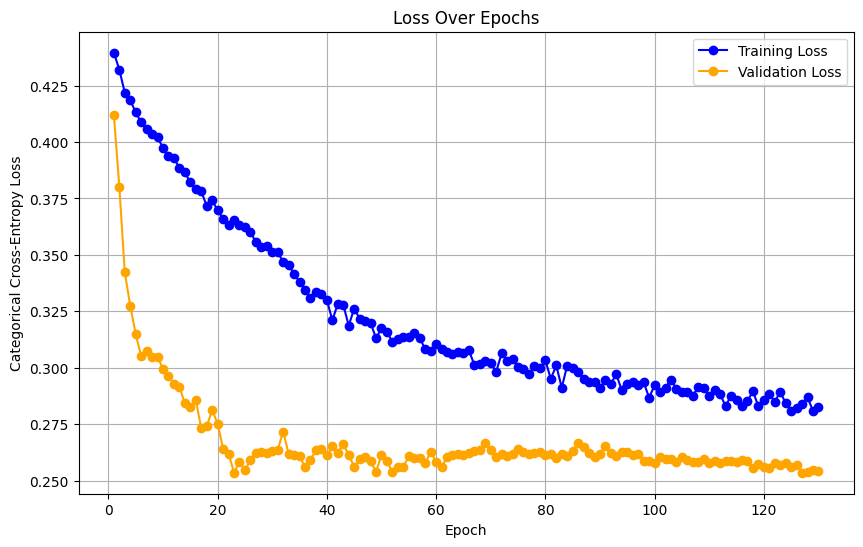

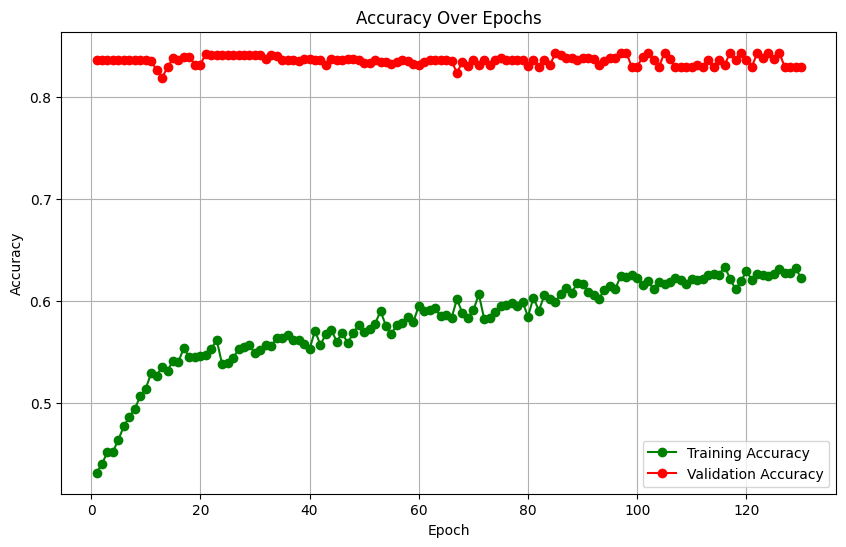

In [63]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o', color='green')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='red')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)

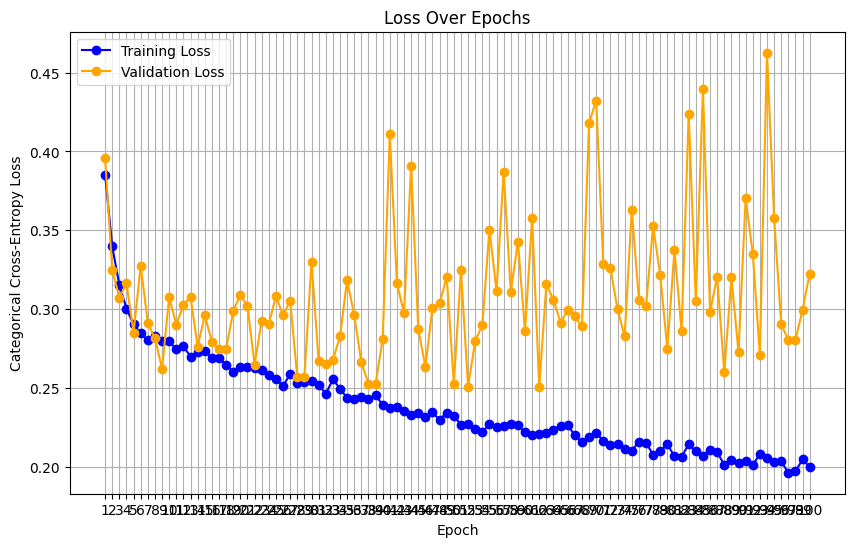

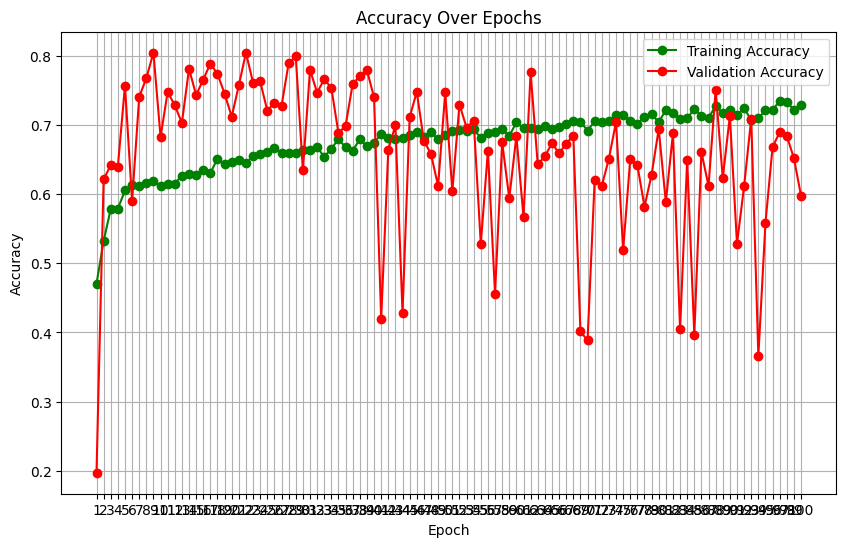

In [ ]:


# Call the function after training
plot_training_history(history)

In [64]:
test_predictions = model.predict([X_test_full, horizon_test_full])
if dirichlet_output:
    probs, alpha, S = dirichlet_layer(test_predictions)
    probs = probs.numpy()
else:
    probs = test_predictions
probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
loss = -np.sum(Y_test_full * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)

loss_reshaped = loss.reshape(forecast_horizon, -1).T
stats = {
    'mean': np.nanmean(loss_reshaped, axis=0),
    'median': np.nanmedian(loss_reshaped, axis=0),
    'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
    'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
    'max': np.nanmax(loss_reshaped, axis=0),
    'min': np.nanmin(loss_reshaped, axis=0)
}

# Convert to DataFrame for better display
lstm_stats_df = pd.DataFrame(stats)
lstm_stats_df

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,mean,median,P25,P75,max,min
0,0.789547,0.683577,0.628959,0.747259,4.111050,0.466484
1,0.812999,0.690431,0.632432,0.769151,4.272134,0.467307
2,0.831805,0.699277,0.638962,0.787496,4.359155,0.467358
3,0.845316,0.704601,0.643561,0.813933,4.357705,0.484409
4,0.852696,0.704754,0.641819,0.817118,4.345135,0.482919
5,0.857143,0.708277,0.646432,0.805319,4.330996,0.474287
6,0.857990,0.706395,0.647416,0.806639,4.363222,0.470231
7,0.851015,0.707083,0.645859,0.800041,4.364380,0.472155
8,0.842068,0.708151,0.646317,0.796220,4.353565,0.471370
9,0.830857,0.708475,0.646250,0.795342,4.342651,0.459220


In [67]:
# Get the most likely state (argmax) for each probability vector
argmax_states = np.argmax(probs_reshaped, axis=2)
# Get value counts of the most likely states across all samples and horizons
state_counts = pd.Series(argmax_states.flatten()).value_counts()
state_counts

2    1718
1    1212
0      70
Name: count, dtype: int64

In [68]:
pd.Series(np.argmax(Y_test_full, axis=1).flatten()).value_counts()

2    1855
1    1061
0      84
Name: count, dtype: int64

In [69]:
probs_reshaped[50, :, :]

array([[0.01411445, 0.42076668, 0.56511885],
       [0.01410921, 0.42056182, 0.56532896],
       [0.01406715, 0.42090243, 0.5650304 ],
       [0.01407748, 0.42142883, 0.56449366],
       [0.01410951, 0.4210213 , 0.5648692 ],
       [0.01411654, 0.42204696, 0.5638366 ],
       [0.01405424, 0.42241392, 0.5635318 ],
       [0.01406715, 0.42090243, 0.5650304 ],
       [0.01406715, 0.42090243, 0.5650304 ],
       [0.01406715, 0.42090243, 0.5650304 ]], dtype=float32)

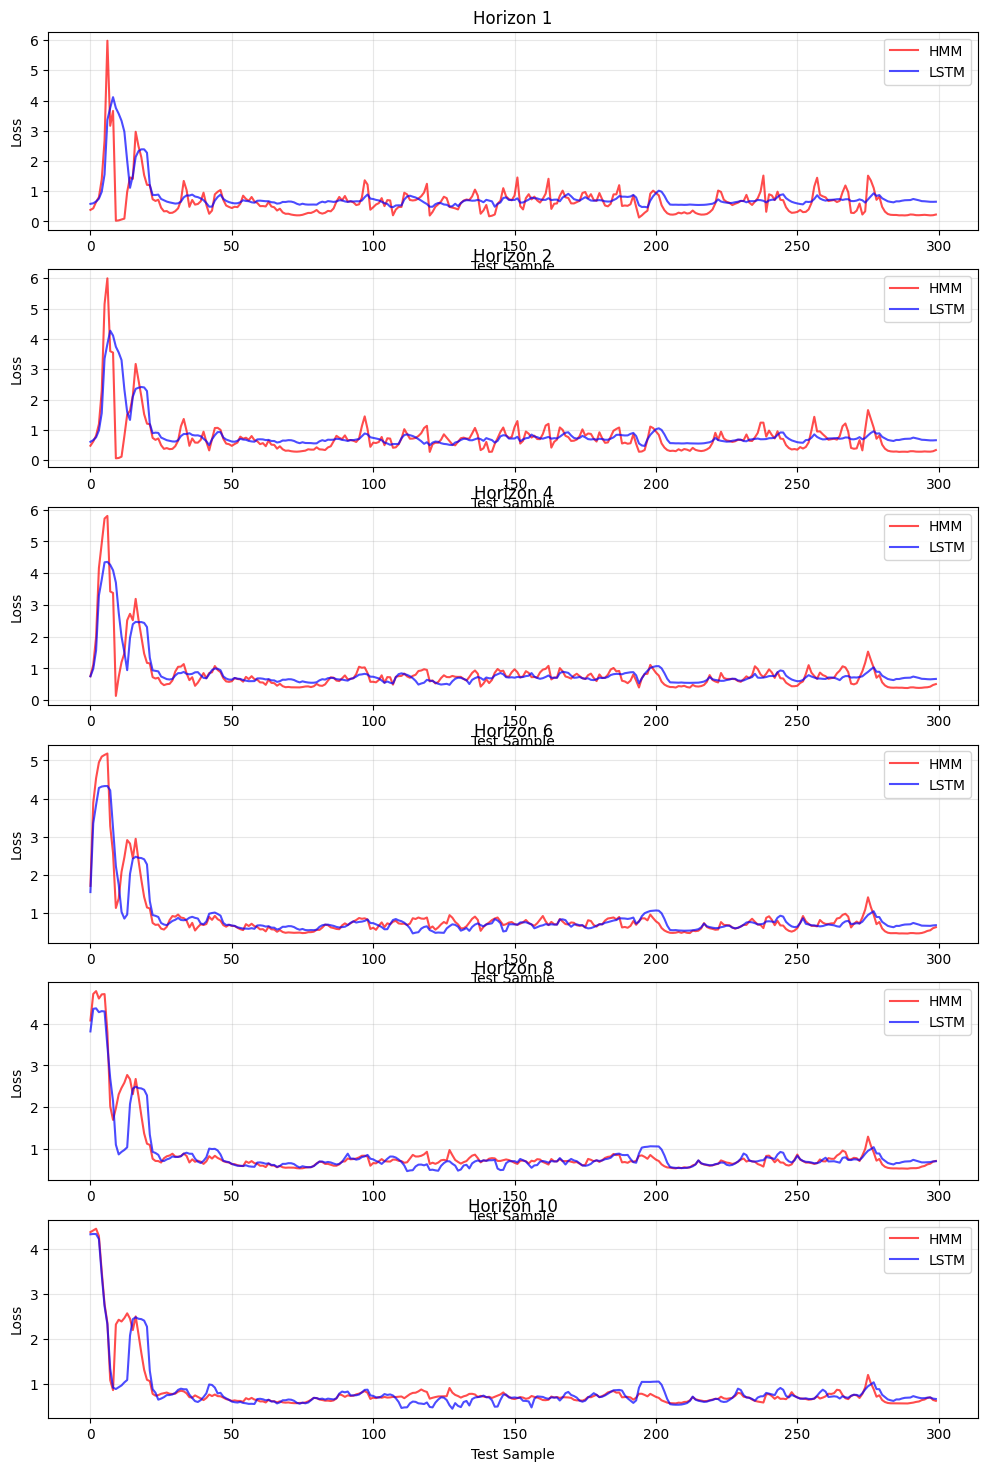

In [70]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

plt.figure(figsize=(12, 18))

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='red', alpha=0.7)
    ax.plot(loss_reshaped[:, horizon], label='LSTM', color='blue', alpha=0.7)
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

## Run hypertuning

In [29]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Concatenate

# Model-building function for hyperparameter tuning
def build_model(hp):
    
    # Tune lookback (history length/timesteps)
    lookback = hp.Choice('lookback', values=[3, 5, 10])
    
    # Tune feature inclusion (one boolean per group of 4 columns)
    include_tsx = hp.Boolean('include_TSX_Composite', default=True)
    include_crude = hp.Boolean('include_Crude_Oil_Futures', default=True)
    include_gold = hp.Boolean('include_Gold_Futures', default=True)
    include_copper = hp.Boolean('include_Copper_Futures', default=True)
    include_sp500 = hp.Boolean('include_SP_500', default=True)
    
    # Build feature mask: 1.0 for included groups, 0.0 for excluded
    feature_mask_list = (
        [1.0] * 4 if include_tsx else [0.0] * 4
    ) + (
        [1.0] * 4 if include_crude else [0.0] * 4
    ) + (
        [1.0] * 4 if include_gold else [0.0] * 4
    ) + (
        [1.0] * 4 if include_copper else [0.0] * 4
    ) + (
        [1.0] * 4 if include_sp500 else [0.0] * 4
    )
    feature_mask = tf.constant(feature_mask_list, dtype=tf.float32)
    
    # Other hyperparameters (unchanged)
    lstm_units = hp.Choice('lstm_units', values=[8, 16, 32, 64])
    dense_units = hp.Choice('dense_units', values=[4, 8, 16, 32])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    # Tune embedding dimension for horizon input
    embedding_dim = hp.Choice('embedding_dim', values=[4, 8, 16])
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    # Primary input for timeseries data
    timeseries_input = layers.Input(shape=X_train_full.shape[1:])
    
    # Auxiliary input for one-hot encoded horizon (length 10)
    horizon_input = layers.Input(shape=(10,))
    
    # Embed the horizon input into a dense representation
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)
    
    # Lambda layer to slice to the last 'lookback' timesteps
    sliced = layers.Lambda(lambda x: x[:, -lookback:, :])(timeseries_input)
    
    # Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
    masked = layers.Lambda(lambda x: x * tf.reshape(feature_mask, (1, 1, 20)))(sliced)
    
    # LSTM layer with added dropout
    lstm_out = layers.LSTM(lstm_units, dropout=dropout_rate)(masked)
    
    # Concatenate LSTM output with embedded horizon
    concat = Concatenate()([lstm_out, horizon_embed])
    
    # Dense layers following concatenation
    dense1 = layers.Dense(dense_units, activation='relu')(concat)
    drop1 = layers.Dropout(dropout_rate)(dense1)
    dense2 = layers.Dense(dense_units, activation='relu')(drop1)
    drop2 = layers.Dropout(dropout_rate)(dense2)
    
    # Output raw evidence (non-negative)
    output = layers.Dense(n_states, activation='softplus')(drop2)
    
    # Define the multi-input model
    model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)
    
    model.compile(
        loss=EvidentialLoss(annealing_rate=30.0),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']  # Accuracy on argmax(probs)
    )
    
    return model

In [30]:
tf.keras.backend.clear_session()
# Initialize the tuner (using Hyperband for efficiency)
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',  # Optimize for validation loss
    max_epochs=75,
    factor=3,
    directory='tuner_dir',
    project_name='evidential_lstm_tuning_v2',
    seed=42
)

# Define callbacks: annealing and early stopping
annealing_callback = AnnealingCallback()
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform the hyperparameter search
tuner.search(
    [X_train_full, horizon_train_full], 
    Y_train_full, 
    epochs=75, 
    validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
    callbacks=[annealing_callback],
    verbose=1  # Adjust verbosity as needed
)

# Retrieve the best model and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=3)[0]

# Optionally, print the best hyperparameters
print(best_hyperparameters.values)

# Summary of the best model
best_model.summary()

Trial 90 Complete [00h 01m 08s]
val_loss: 0.27225595712661743

Best val_loss So Far: 0.16491025686264038
Total elapsed time: 00h 25m 54s
{'lookback': 10, 'include_TSX_Composite': True, 'include_Crude_Oil_Futures': False, 'include_Gold_Futures': True, 'include_Copper_Futures': False, 'include_SP_500': True, 'lstm_units': 64, 'dense_units': 16, 'dropout_rate': 0.1, 'embedding_dim': 16, 'learning_rate': 0.0014866048211473926, 'tuner/epochs': 9, 'tuner/initial_epoch': 3, 'tuner/bracket': 3, 'tuner/round': 1, 'tuner/trial_id': '0007'}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 20)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 20)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     21,760 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │      1,296 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         51 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,555 (92.01 KB)

 Trainable params: 23,555 (92.01 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
tuner.get_best_hyperparameters(num_trials=1)[0].values

{'lookback': 10,
 'include_TSX_Composite': True,
 'include_Crude_Oil_Futures': False,
 'include_Gold_Futures': True,
 'include_Copper_Futures': False,
 'include_SP_500': True,
 'lstm_units': 64,
 'dense_units': 16,
 'dropout_rate': 0.1,
 'embedding_dim': 16,
 'learning_rate': 0.0014866048211473926,
 'tuner/epochs': 9,
 'tuner/initial_epoch': 3,
 'tuner/bracket': 3,
 'tuner/round': 1,
 'tuner/trial_id': '0007'}

Extracted 90 trials for analysis.
ANOVA for lookback: F-statistic=1.25, p-value=0.2928
ANOVA for lstm_units: F-statistic=0.91, p-value=0.4420
ANOVA for dense_units: F-statistic=7.97, p-value=0.0001
ANOVA for embedding_dim: F-statistic=0.23, p-value=0.7962
ANOVA for include_TSX_Composite: F-statistic=24.77, p-value=0.0000
ANOVA for include_Crude_Oil_Futures: F-statistic=0.92, p-value=0.3397
ANOVA for include_Gold_Futures: F-statistic=0.36, p-value=0.5486
ANOVA for include_Copper_Futures: F-statistic=0.02, p-value=0.8940
ANOVA for include_SP_500: F-statistic=5.63, p-value=0.0199
Spearman correlation for dropout_rate: correlation=0.22, p-value=0.0339

Hyperparameter Importances (higher values indicate greater sensitivity):
learning_rate                0.343360
dense_units                  0.161811
include_TSX_Composite        0.130386
tuner/round                  0.071879
tuner/initial_epoch          0.057729
tuner/trial_id               0.045553
dropout_rate                 0.041474
tune

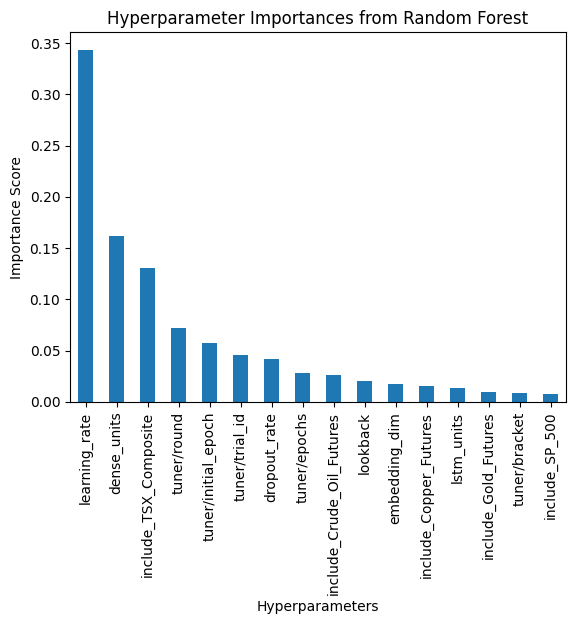

/home/dcs01/.local/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/dcs01/.local/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


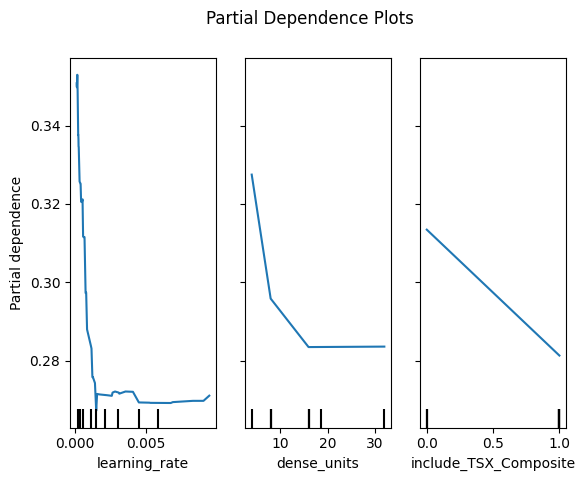

In [32]:
import pandas as pd
from scipy.stats import f_oneway, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Section 1: Extract Trial Data from Tuner
# Access trials from the tuner's oracle and compile into a DataFrame
trials = tuner.oracle.trials.values()
trial_data = []
for trial in trials:
    hps = trial.hyperparameters.values  # Dictionary of hyperparameters
    score = trial.score  # Objective value (e.g., val_loss or val_accuracy)
    trial_data.append({**hps, 'score': score})

df = pd.DataFrame(trial_data)
print(f"Extracted {len(df)} trials for analysis.")

# Section 2: Statistical Tests for Individual Sensitivity
# For discrete/categorical hyperparameters (e.g., 'lookback', 'lstm_units', booleans)
discrete_params = ['lookback', 'lstm_units', 'dense_units', 'embedding_dim',
                   'include_TSX_Composite', 'include_Crude_Oil_Futures',
                   'include_Gold_Futures', 'include_Copper_Futures', 'include_SP_500']

for param in discrete_params:
    unique_values = df[param].unique()
    if len(unique_values) > 1:
        groups = [df[df[param] == val]['score'] for val in unique_values]
        f_stat, p_value = f_oneway(*groups)
        print(f"ANOVA for {param}: F-statistic={f_stat:.2f}, p-value={p_value:.4f}")
        # Interpretation: p-value < 0.05 indicates high sensitivity
    else:
        print(f"{param} has insufficient variation for ANOVA.")

# For continuous hyperparameters (e.g., 'dropout_rate')
continuous_params = ['dropout_rate']
for param in continuous_params:
    corr, p_value = spearmanr(df[param], df['score'])
    print(f"Spearman correlation for {param}: correlation={corr:.2f}, p-value={p_value:.4f}")
    # Interpretation: |correlation| > 0.3 with p-value < 0.05 indicates sensitivity

# Section 3: Surrogate Model for Global Importances and Partial Dependence
# Preprocess: Encode categorical/boolean columns
df_encoded = df.copy()
for col in df_encoded.columns.drop('score'):
    if df_encoded[col].dtype in ['object', 'bool']:
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.drop('score', axis=1)
y = df_encoded['score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Extract and display feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nHyperparameter Importances (higher values indicate greater sensitivity):")
print(importances)

# Visualize importances
importances.plot(kind='bar')
plt.title('Hyperparameter Importances from Random Forest')
plt.xlabel('Hyperparameters')
plt.ylabel('Importance Score')
plt.show()

# Partial Dependence Plots for selected hyperparameters (e.g., top sensitive ones)
selected_params = importances.index[:3].tolist()  # Top 3 for example
PartialDependenceDisplay.from_estimator(rf, X_train, features=selected_params)
plt.suptitle('Partial Dependence Plots')
plt.show()

In [33]:
model = best_model
test_predictions = model.predict([X_test_full, horizon_test_full])
if dirichlet_output:
    probs, alpha, S = dirichlet_layer(test_predictions)
    probs = probs.numpy()
else:
    probs = test_predictions
probs_reshaped = probs.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
loss = -np.sum(Y_test_full * np.log(np.clip(probs, 1e-15, 1.0)), axis=1)

loss_reshaped = loss.reshape(forecast_horizon, -1).T
stats = {
    'mean': np.nanmean(loss_reshaped, axis=0),
    'median': np.nanmedian(loss_reshaped, axis=0),
    'P25': np.nanpercentile(loss_reshaped, 25, axis=0),
    'P75': np.nanpercentile(loss_reshaped, 75, axis=0),
    'max': np.nanmax(loss_reshaped, axis=0),
    'min': np.nanmin(loss_reshaped, axis=0)
}

# Convert to DataFrame for better display
lstm_stats_df = pd.DataFrame(stats)
lstm_stats_df

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


,mean,median,P25,P75,max,min
0,0.887226,0.708653,0.510775,1.056201,3.221133,0.215697
1,0.908475,0.715021,0.529006,1.053081,3.256274,0.237682
2,0.932396,0.721729,0.539914,1.080224,3.359666,0.235159
3,0.923399,0.722032,0.581162,1.027745,3.620862,0.259435
4,0.944634,0.728221,0.598263,1.115443,3.685080,0.263049
5,0.961833,0.736489,0.610979,1.142240,3.735345,0.247762
6,0.971640,0.733913,0.625645,1.147085,3.763330,0.252560
7,0.958288,0.726233,0.638853,1.121314,3.791410,0.284408
8,0.979355,0.731754,0.637902,1.174744,3.764553,0.270427
9,0.962346,0.738702,0.649630,1.134624,3.797771,0.302922


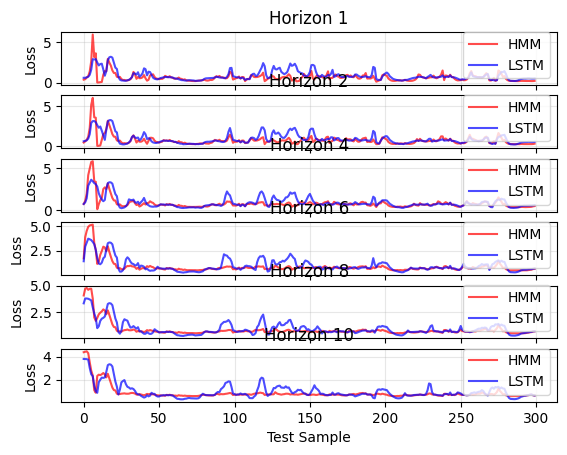

In [34]:
# Horizon indices (0-based): 0, 1, 3
horizons = [0, 1, 3, 5, 7, 9]
titles = ['Horizon 1', 'Horizon 2', 'Horizon 4', 'Horizon 6', 'Horizon 8', 'Horizon 10']

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_state_losses[:, horizon], label='HMM', color='red', alpha=0.7)
    ax.plot(loss_reshaped[:, horizon], label='LSTM', color='blue', alpha=0.7)
    ax.set_title(titles[i])
    ax.set_xlabel('Test Sample')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)


In [25]:
# Get the best hyperparameters which includes the number of epochs trained
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
epochs_trained = best_hp.get('tuner/epochs')
print(f"Number of epochs used to train the best model: {epochs_trained}")

# You can also see the full training configuration
print(f"\nBest model configuration:")
print(f"Trial ID: {best_hp.get('tuner/trial_id')}")
print(f"Epochs: {epochs_trained}")
print(f"Bracket: {best_hp.get('tuner/bracket')}")
print(f"Round: {best_hp.get('tuner/round')}")


Number of epochs used to train the best model: 75

Best model configuration:
Trial ID: 0046
Epochs: 75
Bracket: 3
Round: 3


TypeError: float() argument must be a string or a real number, not 'MetricObservation'

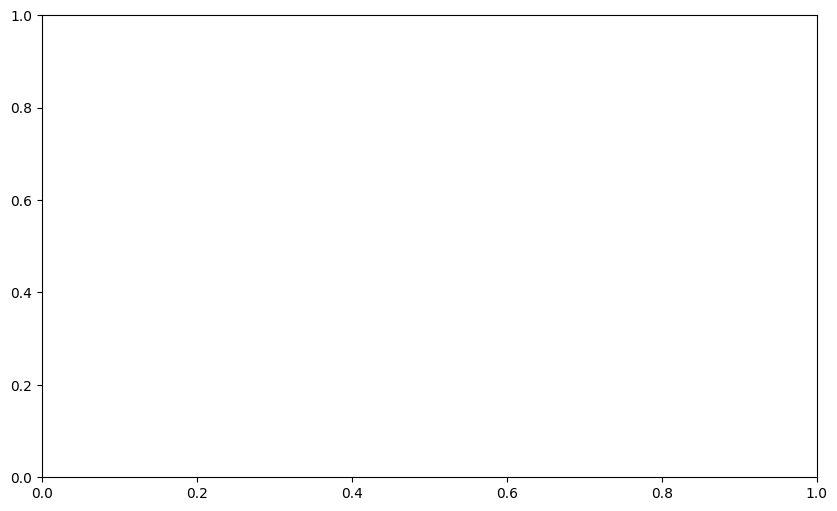

In [26]:
# Get the best trial and extract its training history
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# Extract training and validation loss from the trial metrics
history_data = best_trial.metrics.get_history('loss')
val_history_data = best_trial.metrics.get_history('val_loss')

# Create epochs array
epochs = range(1, len(history_data) + 1)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, history_data, label='Training Loss', marker='o', color='blue')
plt.plot(epochs, val_history_data, label='Validation Loss', marker='o', color='orange')
plt.title('Best Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()